In [11]:
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.model_selection import train_test_split
import pandas as pd

In [12]:
x,y=make_classification( 
    n_samples=300,n_features=4,n_classes=2,random_state=42)

In [13]:
model=RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_split=5,
    random_state=42
)

In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [15]:
model.fit(x_train,y_train)

RandomForestClassifier(max_depth=6, min_samples_split=5, random_state=42)

In [17]:
y_pred=model.predict(x_test)
y_pred

array([0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0])

In [18]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Random Forest Accuracy: 0.9333333333333333

Confusion Matrix:
 [[27  1]
 [ 3 29]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.96      0.93        28
           1       0.97      0.91      0.94        32

    accuracy                           0.93        60
   macro avg       0.93      0.94      0.93        60
weighted avg       0.94      0.93      0.93        60



In [24]:
importance = model.feature_importances_

feature_df = pd.DataFrame({
    'Feature': range(len(importance)),
    'Importance': importance
})

feature_df = feature_df.sort_values(by='Importance', ascending=False)

print("\nFeature Importance:\n", feature_df)


Feature Importance:
    Feature  Importance
0        0    0.394770
2        2    0.285237
1        1    0.261256
3        3    0.058736


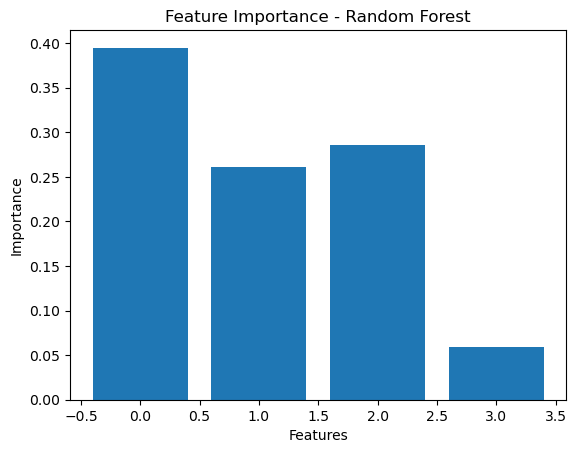

In [25]:
import matplotlib.pyplot as plt

plt.bar(feature_df['Feature'], feature_df['Importance'])
plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()